In [72]:
import casadi as cs
import bifurcations as bf
import dynamics as dn
import numpy as np
from solver import ContinuationSolver
from matplotlib import pyplot as plt
from time import time
from scipy.linalg import null_space

np.set_printoptions(precision=3, suppress=True)

In [73]:
PERIODIC = True
N_STEPS = 100
N_BRANCH = 3
DE_MIN = 1e-6
DE_MAX = 1e-2
U0 = np.array(
    [0.0, 1.01, 0.0, 0.0, 0.0, 0.0, 0.00565685, 0.01525397, 0.00565685, 0.0, 1.01]
    # [0, 1.02334, 0.690765, -2.66782, -9.36157e-28, -1.42652, 0.0198692, 0.00669208, 0.0198692, 3.1187e-14, 4.58196]
)

In [74]:
def estimation(traj_current, dt_current, traj_previous, dt_previous):
    dtraj = traj_current - traj_previous
    traj_next = traj_current + dtraj
    dt_next = dt_current + (dt_current - dt_previous)
    return traj_next, dt_next


def register(traj, dt, branch):
    branch["traj"].append(traj.copy())
    branch["dt"].append(dt.copy())


def init_trajectory(u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = dn.traj_f_list(x0, dt[0], xi)
    traj2 = dn.stance_to_flight(
        dn.traj_s_list(dn.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = dn.traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3)
    return np.array(traj),np.array(dt),xi

def correction_step(solver,u):
    traj,dt,xi = init_trajectory(u)
    solver.initialize(traj,dt,u[-1])
    traj,dt,xi = solver.solve()
    u=cs.vertcat(0,traj[1:,0],dt,xi,dn.energy_flight(traj[:,0]))
    return u,traj,dt

In [75]:
def process_bifurcation(u_, p1):
    u = cs.vertcat(bf.newton(u_[:10],u_[10]),u_[10])
    J = bf.compute_J(u)
    val, vec = np.linalg.eig(cs.vertcat(J, p1.T))
    idx_val = np.argmin(np.abs(val))
    p2 = vec[:, idx_val].real.reshape((11,1))
    p2 =  p2 - np.dot(p1.T,p2) * p1 
    p2 = p2 / np.linalg.norm(p2)
    val, vec = np.linalg.eig(J @ J.T)
    idx_val = np.argmin(np.abs(val))
    e = vec[:, idx_val].real
    b12 = bf.hessian(u, p1, p2, e)
    b22 = bf.hessian(u, p2, p2, e)
    beta2 = 1
    beta1 = -b22 / (2 * b12)
    p2 = beta1 * p1 + beta2 * p2
    p2 = p2 / np.linalg.norm(p2)
    return p2

In [76]:
traj_init,dt_init,xi_init = init_trajectory(cs.vertcat(bf.newton(U0[:10],U0[10]),U0[10]))
p_init = null_space(bf.compute_J(U0[:11]))
solver = ContinuationSolver(PERIODIC)

In [77]:
def unconstrained_continuation(solver,u,p,d,N):
    u_star,p1,p2 = None,None,None
    branch = {"traj":[],"dt":[]}
    u,traj,dt = correction_step(solver,u)
    register(traj,dt,branch)
    det_hist = []
    u_hist = []
    p_hist = []

    for step in range(N):
        u = u + np.sign(p[-1])*d*p
        if step >= 2:
            u,traj,dt = correction_step(solver,u)
            u = cs.vertcat(bf.newton(u[:10],u[10]),u[10])
        else: 
            traj,dt,_ = init_trajectory(u)
        u_hist.append(u)
        register(traj,dt,branch)
        J = bf.compute_J(u) 
        p = null_space(J)
        p_hist.append(p)
        det_hist.append(np.linalg.det(cs.vertcat(J,p.T)))
        if step>10 and det_hist[-2]*det_hist[-1] < 0:
            coeff = det_hist[-2]/(det_hist[-2] - det_hist[-1])
            u_star = coeff * u_hist[-1] + (1-coeff) * u_hist[-2]
            p1 = coeff * p_hist[-1] + (1-coeff) * p_hist[-2]
            p2 = process_bifurcation(u_star,p1)
            break

    return branch,det_hist,u_star,p1,p2

    

In [78]:
branch,det,u_star,p1,p2 = unconstrained_continuation(solver,U0,p_init,0.005,100)
branch_2,det_2,_,_,_ = unconstrained_continuation(solver,u_star,p2,0.25,100)
branch_1,det_1,u_star,p1,p2 = unconstrained_continuation(solver,u_star,p1,0.005,100)
print(u_star)
print(p2)
branch_3,det_3,_,_,_ = unconstrained_continuation(solver,u_star,p2,0.25,100)

[0, 1.27185, 1.51519e-28, -1.01806e-24, 1.27975e-21, -1.1857e-24, 0.0294945, 0.0112705, 0.0294945, 4.19339e-08, 1.27185]
[0.00654032, -0.022594, -4.53337e-06, -0.650701, -3.03803e-05, -0.757915, -6.28008e-05, 1.92224e-05, -0.00154353, 0.0329806, -0.0225829]


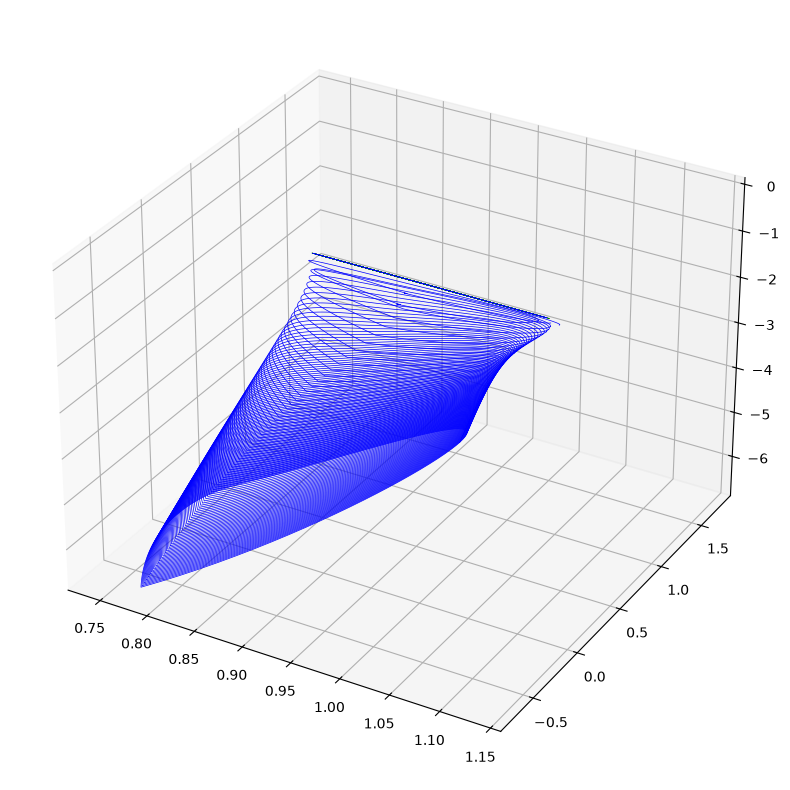

In [82]:
def plot_traj(ax,traj,c):
    ax.plot(traj[1,:],traj[2,:],traj[3,:], linewidth=0.5,color=c)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1,projection="3d")
for t in branch["traj"]:
    plot_traj(ax, t,"green")
for t in branch_2["traj"]:
    plot_traj(ax, t,"blue")
# for t in branch_3["traj"]:
#     plot_traj(ax, t,"red")
# plt.plot(np.array(branch_3["traj"])[:,1,0],np.array(branch_3["traj"])[:,2,0],np.array(branch_3["traj"])[:,3,0])

# u_star_star = u_star + 0.005*p2
# # u_star_star = cs.vertcat(bf.newton(u_star_star[:10],u_star_star[10]),u_star_star[10])
# traj_test ,_,_ = init_trajectory(u_star_star)
# print(bf.residual(u_star_star))
# plot_traj(ax,traj_test,'red')


# plt.plot(dn.energy_flight(np.array(branch_1["traj"])[1:,:,0].T).T,np.sign(det_1))
# plt.ylim(-1,1)
plt.show()

In [80]:
"""
TODO 
1. Implement better jacobian computation for J
2. Add orthogonality constraint ? (maybe clash with the E=Ed constraint)
3. implement simple/multiple shooting correction step with exactly the same state as prediction
"""

'\nTODO \n1. Implement better jacobian computation for J\n2. Add orthogonality constraint ? (maybe clash with the E=Ed constraint)\n3. implement simple/multiple shooting correction step with exactly the same state as prediction\n'